   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.8 MB/s eta 0:00:00
Using device: cuda
Path: /kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation
Total pairs: 2594
Computing lesion areas...


100%|██████████| 2594/2594 [02:11<00:00, 19.66it/s]


33rd pct: 0.0715 | 66th pct: 0.2416
Small:856  Medium:856  Large:882
Train: 2075 | Test: 519

✅ Partitions verified. Sizes: [688, 687, 700]
  Client 0: {'small': 548, 'large': 71, 'medium': 69}
  Client 1: {'medium': 548, 'large': 70, 'small': 69}
  Client 2: {'large': 564, 'medium': 68, 'small': 68}
Val:415 | Test:519
Using SMP U-Net


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Output shape: torch.Size([2, 1, 256, 256])

MAIN TRAINING — frac=0.8, rounds=20

RUNNING FEDAVG
  Round 1/20 fedavg → Dice:0.8177  IoU:0.7186
  Round 2/20 fedavg → Dice:0.8564  IoU:0.7712
  Round 3/20 fedavg → Dice:0.8829  IoU:0.8091
  Round 4/20 fedavg → Dice:0.8933  IoU:0.8245
  Round 5/20 fedavg → Dice:0.8986  IoU:0.8310
  Round 6/20 fedavg → Dice:0.9061  IoU:0.8418
  Round 7/20 fedavg → Dice:0.9022  IoU:0.8384
  Round 8/20 fedavg → Dice:0.9024  IoU:0.8383
  Round 9/20 fedavg → Dice:0.9099  IoU:0.8489
  Round 10/20 fedavg → Dice:0.9087  IoU:0.8469
  Round 11/20 fedavg → Dice:0.9067  IoU:0.8442
  Round 12/20 fedavg → Dice:0.9117  IoU:0.8506
  Round 13/20 fedavg → Dice:0.9112  IoU:0.8534
  Round 14/20 fedavg → Dice:0.9185  IoU:0.8628
  Round 15/20 fedavg → Dice:0.9206  IoU:0.8648
  Round 16/20 fedavg → Dice:0.9188  IoU:0.8624
  Round 17/20 fedavg → Dice:0.9183  IoU:0.8642
  Round 18/20 fedavg → Dice:0.9202  IoU:0.8656
  Round 19/20 fedavg → Dice:0.9179  IoU:0.8608
  Round 20/20 fedavg

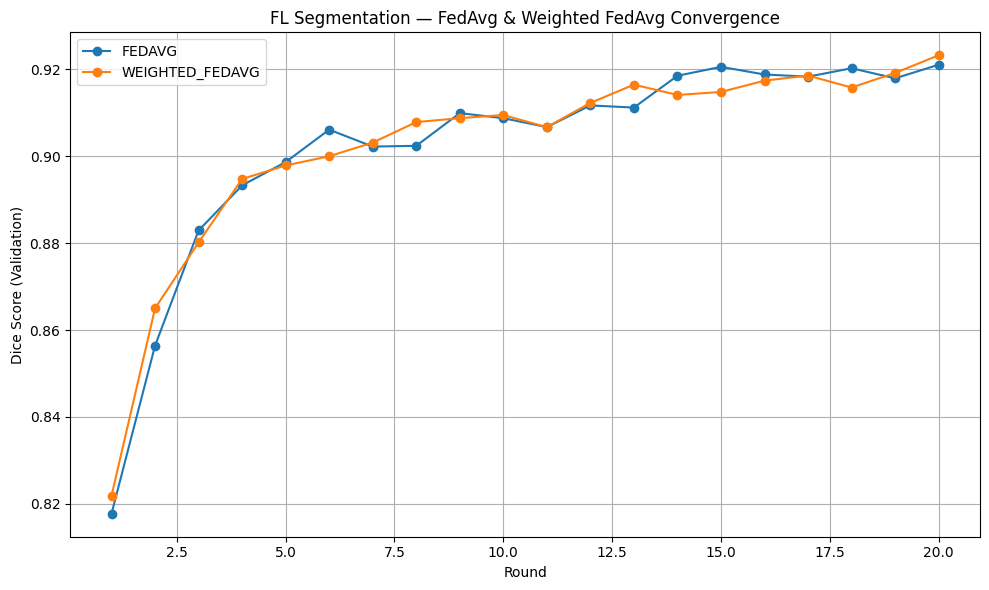

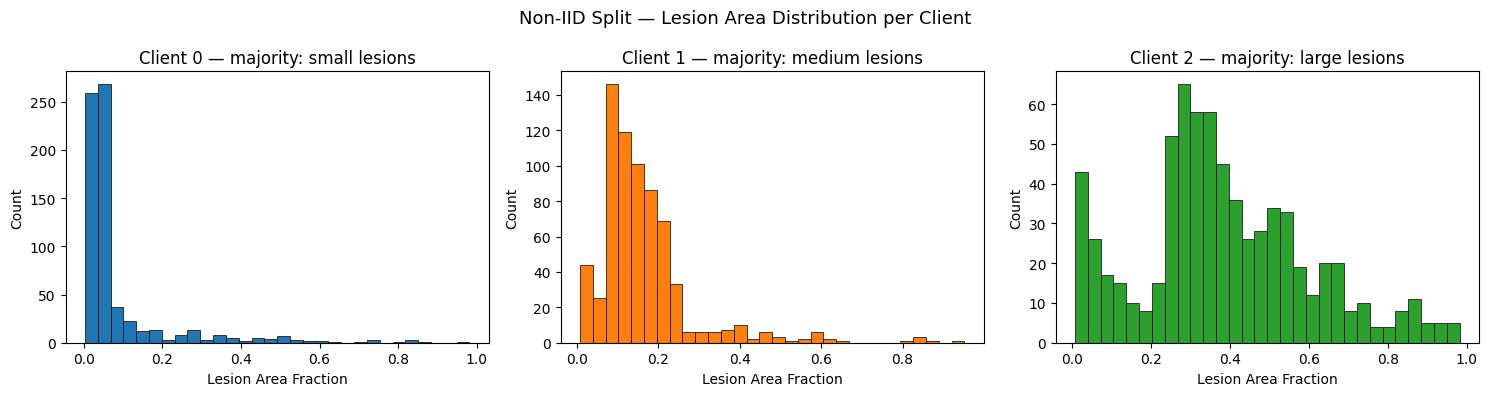


✅ Notebook 1A complete.

Files saved:
  fl_results_part_a.csv
  final_model_fedavg.pth
  final_model_weighted_fedavg.pth
  client_fedavg_0/1/2.pth
  client_weighted_fedavg_0/1/2.pth
  test_df.csv, train_df.csv, meta.json
  client_0/1/2_train.csv
  client_0/1/2_test_split.csv
  convergence_part_a.png
  noniid_distribution.png

➡ Save output as Kaggle dataset: 'isic2018-seg-part-a'


In [1]:
# ==========================================
# NOTEBOOK 1A: FL SEGMENTATION
# Methods: FedAvg + Weighted FedAvg
# Dataset: ISIC-2018 Task 1
# Non-IID: Lesion area split
# ==========================================

!pip install -q kagglehub scikit-learn tqdm segmentation-models-pytorch

import os, copy, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
from collections import OrderedDict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. DATASET
# ==========================================
import kagglehub
path = kagglehub.dataset_download(
    "tschandl/isic2018-challenge-task1-data-segmentation")
print(f"Path: {path}")

TRAIN_IMG_DIR  = os.path.join(path, "ISIC2018_Task1-2_Training_Input")
TRAIN_MASK_DIR = os.path.join(path, "ISIC2018_Task1_Training_GroundTruth")

# ==========================================
# 2. BUILD IMAGE-MASK PAIRS
# ==========================================
def build_pairs(img_dir, mask_dir):
    img_files = {
        os.path.splitext(f)[0]: os.path.join(img_dir, f)
        for f in os.listdir(img_dir)
        if f.lower().endswith(('.jpg','.jpeg','.png'))
    }
    mask_files = {
        os.path.splitext(f)[0].replace('_segmentation',''):
        os.path.join(mask_dir, f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith('.png')
    }
    return [{'image_id': b, 'image': img_files[b], 'mask': mask_files[b]}
            for b in img_files if b in mask_files]

pairs = build_pairs(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
print(f"Total pairs: {len(pairs)}")

# ==========================================
# 3. LESION AREA + NON-IID LABELS
# ==========================================
print("Computing lesion areas...")
areas = []
for p in tqdm(pairs):
    mask  = np.array(Image.open(p['mask']).convert("L"))
    areas.append((mask > 127).sum() / mask.size)

df            = pd.DataFrame(pairs)
df['lesion_area'] = areas

p33 = df['lesion_area'].quantile(0.33)
p66 = df['lesion_area'].quantile(0.66)
print(f"33rd pct: {p33:.4f} | 66th pct: {p66:.4f}")

df['size_label'] = df['lesion_area'].apply(
    lambda a: 0 if a <= p33 else (1 if a <= p66 else 2))

print(f"Small:{(df['size_label']==0).sum()}  "
      f"Medium:{(df['size_label']==1).sum()}  "
      f"Large:{(df['size_label']==2).sum()}")

# ==========================================
# 4. TRAIN / TEST SPLIT
# ==========================================
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['size_label'], random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

# ==========================================
# 5. DISJOINT NON-IID CLIENT SPLIT
# ==========================================
majority_classes_per_client = [[0], [1], [2]]

def disjoint_split(df, majority_per_client,
                   majority_frac=0.8, seed=42):
    np.random.seed(seed)
    labels  = df['size_label'].values
    n_cl    = len(majority_per_client)
    assigned = np.full(len(df), -1, dtype=int)

    for lbl in np.unique(labels):
        pos = np.where(labels == lbl)[0].tolist()
        np.random.shuffle(pos)
        owner = next(
            (c for c, g in enumerate(majority_per_client) if lbl in g), 0)
        n_maj = int(len(pos) * majority_frac)
        for i in pos[:n_maj]: assigned[i] = owner
        others = [c for c in range(n_cl) if c != owner]
        for c, chunk in zip(
                others,
                np.array_split(pos[n_maj:], max(len(others), 1))):
            for i in chunk: assigned[i] = c

    assigned[assigned == -1] = 0
    for ci in range(n_cl):
        for cj in range(ci+1, n_cl):
            assert set(np.where(assigned==ci)[0]).isdisjoint(
                   set(np.where(assigned==cj)[0])), \
                   f"Overlap between {ci} and {cj}!"
    return [df.iloc[np.where(assigned==c)[0]].reset_index(drop=True)
            for c in range(n_cl)]

MAIN_FRAC  = 0.8
client_dfs = disjoint_split(
    train_df, majority_classes_per_client, majority_frac=MAIN_FRAC)
client_sizes = [len(c) for c in client_dfs]

print(f"\n✅ Partitions verified. Sizes: {client_sizes}")
size_map = {0:'small', 1:'medium', 2:'large'}
for i, cdf in enumerate(client_dfs):
    cnts = {size_map[k]:v
            for k,v in cdf['size_label'].value_counts().to_dict().items()}
    print(f"  Client {i}: {cnts}")

# ==========================================
# 6. DATASET CLASS
# ==========================================
IMG_SIZE = 256

img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
mask_tf = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE),
        interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

class SegDataset(Dataset):
    def __init__(self, df, img_tf=None, mask_tf=None, noise=0.0):
        self.df=df.reset_index(drop=True)
        self.img_tf=img_tf; self.mask_tf=mask_tf; self.noise=noise
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(row['image']).convert("RGB")
        mask = Image.open(row['mask']).convert("L")
        if self.img_tf:  img  = self.img_tf(img)
        if self.mask_tf: mask = self.mask_tf(mask)
        mask = (mask > 0.5).float()
        if self.noise > 0:
            img += torch.randn_like(img) * self.noise / 255.0
            img  = torch.clamp(img, 0, 1)
        return img, mask, row['size_label']

def make_loader(df, noise=0.0, batch_size=8, shuffle=False):
    return DataLoader(
        SegDataset(df, img_tf, mask_tf, noise),
        batch_size=batch_size, shuffle=shuffle,
        num_workers=2, pin_memory=True)

NOISE = [0.0, 15.0, 10.0]
dataloaders = [make_loader(cdf, noise=NOISE[i])
               for i, cdf in enumerate(client_dfs)]
val_df      = train_df.sample(frac=0.2, random_state=42)
val_loader  = make_loader(val_df)
test_loader = make_loader(test_df)
print(f"Val:{len(val_df)} | Test:{len(test_df)}")

# ==========================================
# 7. MODEL — U-Net (ResNet-18 encoder)
# ==========================================
try:
    import segmentation_models_pytorch as smp
    def get_model():
        return smp.Unet(
            encoder_name="resnet18", encoder_weights="imagenet",
            in_channels=3, classes=1).to(device)
    print("Using SMP U-Net")
except ImportError:
    class DoubleConv(nn.Module):
        def __init__(self,ic,oc):
            super().__init__()
            self.c=nn.Sequential(
                nn.Conv2d(ic,oc,3,padding=1,bias=False),
                nn.BatchNorm2d(oc),nn.ReLU(inplace=True),
                nn.Conv2d(oc,oc,3,padding=1,bias=False),
                nn.BatchNorm2d(oc),nn.ReLU(inplace=True))
        def forward(self,x): return self.c(x)
    class UNet(nn.Module):
        def __init__(self,features=[64,128,256,512]):
            super().__init__()
            self.downs=nn.ModuleList(); self.ups=nn.ModuleList()
            self.pool=nn.MaxPool2d(2); c=3
            for f in features: self.downs.append(DoubleConv(c,f)); c=f
            self.bottleneck=DoubleConv(features[-1],features[-1]*2)
            for f in reversed(features):
                self.ups.append(nn.ConvTranspose2d(f*2,f,2,stride=2))
                self.ups.append(DoubleConv(f*2,f))
            self.final=nn.Conv2d(features[0],1,1)
        def forward(self,x):
            skips=[]
            for d in self.downs: x=d(x); skips.append(x); x=self.pool(x)
            x=self.bottleneck(x); skips=skips[::-1]
            for i in range(0,len(self.ups),2):
                x=self.ups[i](x); sk=skips[i//2]
                if x.shape!=sk.shape: x=F.interpolate(x,size=sk.shape[2:])
                x=self.ups[i+1](torch.cat([sk,x],dim=1))
            return self.final(x)
    def get_model(): return UNet().to(device)
    print("Using custom U-Net")

# Shape test
_m=get_model(); _x=torch.randn(2,3,IMG_SIZE,IMG_SIZE).to(device)
print(f"Output shape: {_m(_x).shape}"); del _m,_x
torch.cuda.empty_cache()

# ==========================================
# 8. LOSS + METRICS
# ==========================================
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce=nn.BCEWithLogitsLoss(); self.s=smooth
    def forward(self, logits, targets):
        bce=self.bce(logits,targets); p=torch.sigmoid(logits)
        i=(p*targets).sum(dim=(2,3))
        d=1-(2*i+self.s)/(p.sum(dim=(2,3))+targets.sum(dim=(2,3))+self.s)
        return bce+d.mean()

criterion = DiceBCELoss()

def compute_metrics(logits, masks, thr=0.5):
    preds=(torch.sigmoid(logits)>thr).float(); s=1e-6
    tp=(preds*masks).sum(dim=(2,3))
    fp=(preds*(1-masks)).sum(dim=(2,3))
    fn=((1-preds)*masks).sum(dim=(2,3))
    tn=((1-preds)*(1-masks)).sum(dim=(2,3))
    return {
        'dice':        ((2*tp+s)/(2*tp+fp+fn+s)).mean().item(),
        'iou':         ((tp+s)/(tp+fp+fn+s)).mean().item(),
        'pixel_acc':   ((tp+tn+s)/(tp+fp+fn+tn+s)).mean().item(),
        'sensitivity': ((tp+s)/(tp+fn+s)).mean().item(),
        'specificity': ((tn+s)/(tn+fp+s)).mean().item(),
    }

def evaluate(model, loader):
    model.eval(); all_m=[]
    with torch.no_grad():
        for batch in loader:
            imgs,masks=batch[0].to(device),batch[1].to(device)
            all_m.append(compute_metrics(model(imgs),masks))
    return {k:float(np.mean([m[k] for m in all_m])) for k in all_m[0]}

# ==========================================
# 9. LOCAL TRAINING
# ==========================================
MU = 0.001

def train_local(model, loader, gw,
                local_epochs=3, lr=1e-4, mu=0.0):
    model.train()
    opt=optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    for _ in range(local_epochs):
        for batch in loader:
            imgs,masks=batch[0].to(device),batch[1].to(device)
            opt.zero_grad(); loss=criterion(model(imgs),masks)
            if mu > 0:
                loss+=(mu/2)*sum(
                    torch.sum((p-gw[n].to(device))**2)
                    for n,p in model.named_parameters()
                    if n in gw and p.dtype.is_floating_point)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step()
    return {k:v.cpu().clone() for k,v in model.state_dict().items()}

# ==========================================
# 10. AGGREGATION
# ==========================================
def fedavg_agg(lw):
    avg=OrderedDict()
    for k in lw[0]:
        t=[w[k] for w in lw]
        avg[k]=torch.stack(t).mean(0) \
               if t[0].dtype.is_floating_point else t[0].clone()
    return avg

def weighted_fedavg_agg(lw, sizes):
    total=sum(sizes); avg=OrderedDict()
    for k in lw[0]:
        t=[w[k] for w in lw]
        avg[k]=sum(w[k]*(s/total) for w,s in zip(lw,sizes)) \
               if t[0].dtype.is_floating_point else t[0].clone()
    return avg

# ==========================================
# 11. FL RUNNER
# ==========================================
def run_fl(name, dataloaders, client_sizes,
           rounds=20, local_epochs=3, lr=1e-4,
           save_clients=True):

    gm  = get_model()
    gw  = {k:v.cpu() for k,v in gm.state_dict().items()}
    cms = [get_model() for _ in range(3)]
    best_dice, best_gw = -1.0, None
    history = []

    for rnd in range(rounds):
        lw=[]
        for cid, loader in enumerate(dataloaders):
            cms[cid].load_state_dict(gw, strict=True)
            lw.append(train_local(
                cms[cid], loader, gw,
                local_epochs=local_epochs, lr=lr,
                mu=(MU if name=='fedprox' else 0.0)))

        if   name=='fedavg':
            gw = fedavg_agg(lw)
        elif name=='weighted_fedavg':
            gw = weighted_fedavg_agg(lw, client_sizes)

        gm.load_state_dict(gw, strict=True)
        val_m = evaluate(gm, val_loader)
        history.append({
            'round':rnd, 'aggregation':name,
            'dice':val_m['dice'], 'iou':val_m['iou'],
            'pixel_acc':val_m['pixel_acc'],
            'sensitivity':val_m['sensitivity'],
            'specificity':val_m['specificity'],
        })
        print(f"  Round {rnd+1}/{rounds} {name} → "
              f"Dice:{val_m['dice']:.4f}  IoU:{val_m['iou']:.4f}")

        if val_m['dice'] > best_dice:
            best_dice = val_m['dice']
            best_gw   = copy.deepcopy(gw)

    gm.load_state_dict(best_gw, strict=True)

    if save_clients:
        for cid in range(3):
            torch.save(cms[cid].state_dict(),
                       f"/kaggle/working/client_{name}_{cid}.pth")

    fm = evaluate(gm, test_loader)
    return history, gm, cms, fm

# ==========================================
# 12. MAIN RUN — FedAvg + Weighted FedAvg
# ==========================================
ROUNDS       = 20
LOCAL_EPOCHS = 3
LR           = 1e-4
METHODS      = ['fedavg', 'weighted_fedavg']

print(f"\n{'='*60}")
print(f"MAIN TRAINING — frac={MAIN_FRAC}, rounds={ROUNDS}")
print(f"{'='*60}")

all_history = []
final_models = {}
final_metrics = {}

for name in METHODS:
    print(f"\n{'='*50}\nRUNNING {name.upper()}\n{'='*50}")
    hist, gm, cms, fm = run_fl(
        name, dataloaders, client_sizes,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, lr=LR,
        save_clients=True)

    for rec in hist: all_history.append(rec)
    final_models[name]  = gm
    final_metrics[name] = fm

    torch.save(gm.state_dict(),
               f"/kaggle/working/final_model_{name}.pth")
    print(f"✅ {name} → Dice={fm['dice']:.4f}  IoU={fm['iou']:.4f}")

# ==========================================
# 13. SAVE ALL ARTIFACTS
# ==========================================
pd.DataFrame(all_history).to_csv(
    "/kaggle/working/fl_results_part_a.csv", index=False)
test_df.to_csv("/kaggle/working/test_df.csv",   index=False)
train_df.to_csv("/kaggle/working/train_df.csv", index=False)

for i, cdf in enumerate(client_dfs):
    cdf.to_csv(f"/kaggle/working/client_{i}_train.csv", index=False)

    # Per-client test split for unlearning evaluation
    _, cdf_test = train_test_split(
        cdf, test_size=0.2, random_state=42,
        stratify=cdf['size_label']
        if cdf['size_label'].nunique() > 1 else None)
    cdf_test.to_csv(
        f"/kaggle/working/client_{i}_test_split.csv", index=False)

with open("/kaggle/working/meta.json", "w") as f:
    json.dump({
        'majority_classes_per_client': majority_classes_per_client,
        'client_sizes':                client_sizes,
        'img_size':                    IMG_SIZE,
        'main_frac':                   MAIN_FRAC,
        'p33':                         p33,
        'p66':                         p66,
        'train_img_dir':               TRAIN_IMG_DIR,
        'train_mask_dir':              TRAIN_MASK_DIR,
    }, f)

# Convergence plot for Part A
df_h = pd.DataFrame(all_history)
plt.figure(figsize=(10, 6))
colors = {'fedavg':'#1f77b4', 'weighted_fedavg':'#ff7f0e'}
for name in METHODS:
    sub = df_h[df_h['aggregation']==name]
    plt.plot(sub['round']+1, sub['dice'], marker='o',
             color=colors[name], label=name.upper())
plt.xlabel('Round'); plt.ylabel('Dice Score (Validation)')
plt.title('FL Segmentation — FedAvg & Weighted FedAvg Convergence')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_part_a.png", dpi=150)
plt.show()

# Non-IID distribution plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for i, cdf in enumerate(client_dfs):
    clr = ['#1f77b4','#ff7f0e','#2ca02c'][i]
    axes[i].hist(cdf['lesion_area'], bins=30,
                 color=clr, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f"Client {i} — majority: "
                      f"{size_map[i]} lesions")
    axes[i].set_xlabel('Lesion Area Fraction')
    axes[i].set_ylabel('Count')
plt.suptitle('Non-IID Split — Lesion Area Distribution per Client',
             fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/noniid_distribution.png", dpi=150)
plt.show()

print("\n✅ Notebook 1A complete.")
print("\nFiles saved:")
print("  fl_results_part_a.csv")
print("  final_model_fedavg.pth")
print("  final_model_weighted_fedavg.pth")
print("  client_fedavg_0/1/2.pth")
print("  client_weighted_fedavg_0/1/2.pth")
print("  test_df.csv, train_df.csv, meta.json")
print("  client_0/1/2_train.csv")
print("  client_0/1/2_test_split.csv")
print("  convergence_part_a.png")
print("  noniid_distribution.png")
print("\n➡ Save output as Kaggle dataset: 'isic2018-seg-part-a'")